# Time-Series Datasets in `generatedata`

This notebook documents and demonstrates the **time-series / sequence** layer added to the library.  
Three components work together:

| Component | Location | What it does |
|---|---|---|
| `save_data(..., seq_len, step_size)` | `generatedata/save_data.py` | Stores sequence metadata alongside the flat parquet files |
| `generate_mnist_sequence()` / `generate_mnist1d_sequence()` | `generatedata/data_generators.py` | Generates MNIST-family datasets with sequence metadata |
| `load_data_as_sequence()` | `generatedata/load_data.py` | Loads the flat data and reshapes it into `(num_points, seq_len, step_size)` |

The flat parquet storage format is **unchanged** — sequence metadata is purely descriptive and lives in `info.json`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

from generatedata.load_data import load_data, load_data_as_sequence, data_names

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

---
## 1  API Reference

### 1.1  `save_data()` — new parameters

```python
save_data(
    data_dir,
    name: str,
    start_data: dict,
    target_data: dict,
    x_y_index: int | None = None,
    onehot_y: bool = False,
    additional_info: dict | None = None,
    seq_len: int | None = None,   # ← NEW: number of timesteps
    step_size: int | None = None, # ← NEW: features per timestep
) -> None
```

When both `seq_len` and `step_size` are provided:
- Validates `seq_len * step_size == x_y_index` (raises `ValueError` otherwise)
- Writes `seq_len` and `step_size` into `info.json` for downstream loaders

---

### 1.2  `generate_mnist_sequence()` / `generate_mnist1d_sequence()`

```python
generate_mnist_sequence(
    data_dir: Path,
    num_points: int = 1000,
    pixels_per_step: int = 1,        # step_size
    dataset_name: str = "MNIST",     # or 'EMNIST', 'KMNIST', 'FashionMNIST'
) -> None

generate_mnist1d_sequence(
    data_dir: Path,
    num_points: int = 1000,
    pixels_per_step: int = 1,
) -> None
```

**Naming convention** — the generated dataset name encodes the variant:

| Call | Dataset name |
|---|---|
| `generate_mnist_sequence(pixels_per_step=1)` | `MNIST_seq1` |
| `generate_mnist_sequence(pixels_per_step=28, dataset_name='FashionMNIST')` | `FashionMNIST_seq28` |
| `generate_mnist1d_sequence(pixels_per_step=1)` | `MNIST1D_seq1` |
| `generate_mnist1d_sequence(pixels_per_step=5)` | `MNIST1D_seq5` |

---

### 1.3  `load_data_as_sequence()` — the new load function

```python
load_data_as_sequence(
    name: str,
    local: bool = False,
    data_dir: Path | str | None = None,
    label_every_step: bool = True,
) -> tuple[np.ndarray, np.ndarray]
```

**Parameters**

| Parameter | Description |
|---|---|
| `name` | Dataset name (must have `seq_len` / `step_size` in metadata) |
| `local` | Load from the local `data/processed/` directory |
| `data_dir` | Override the default data directory path |
| `label_every_step` | If `True`, broadcast the label vector to every timestep and concatenate with the pixel sequence |

**Return shapes**

| `label_every_step` | `X_seq.shape` | `labels.shape` |
|---|---|---|
| `True` (default) | `(num_points, seq_len, step_size + label_dim)` | `(num_points, label_dim)` |
| `False` | `(num_points, seq_len, step_size)` | `(num_points, label_dim)` |

Both modes always return a consistent `(X_seq, labels)` two-tuple.  
Calling on a dataset **without** sequence metadata raises a helpful `ValueError`.

---
## 2  Discovering available sequence datasets

In [2]:
all_names = data_names(local=True)
seq_names = [n for n in all_names if '_seq' in n]

print(f"All available datasets ({len(all_names)}):")
for n in sorted(all_names):
    tag = "  ← sequence" if '_seq' in n else ""
    print(f"  {n}{tag}")

All available datasets (14):
  EMlocalization
  LunarLander
  MNIST
  MNIST1D
  MNIST1D_seq1  ← sequence
  MNIST1Dcustom_scale0.4_maxtrans48_corrnoise0.25_iidnoise0.02_shear0.75
  MNIST_custom_degrees0_0_translate0_0_scale1_1
  MNIST_seq1  ← sequence
  MassSpec
  circle
  manifold
  pca_line
  regression_circle
  regression_line


---
## 3  Inspecting sequence metadata

The `info` dict returned by `load_data()` carries the sequence parameters written by `save_data()`.

In [3]:
for name in seq_names:
    info = load_data(name, local=True)["info"]
    print(f"\n=== {name} ===")
    for k, v in info.items():
        print(f"  {k:15s}: {v}")


=== MNIST1D_seq1 ===
  num_points     : 1000
  size           : 50
  x_y_index      : 40
  x_size         : 40
  y_size         : 10
  onehot_y       : 1
  seq_len        : 40
  step_size      : 1
  data_family    : MNIST1D

=== MNIST_seq1 ===
  num_points     : 1000
  size           : 794
  x_y_index      : 784
  x_size         : 784
  y_size         : 10
  onehot_y       : 1
  seq_len        : 784
  step_size      : 1
  data_family    : MNIST


---
## 4  Basic loading — shapes and dtypes

In [4]:
# Choose a dataset to explore in this section
DATASET = "MNIST_seq1"

# --- label_every_step=True (default) ---
X_true, labels_true = load_data_as_sequence(DATASET, local=True, label_every_step=True)
print("label_every_step=True")
print(f"  X_seq  shape : {X_true.shape}   dtype: {X_true.dtype}")
print(f"  labels shape : {labels_true.shape}   dtype: {labels_true.dtype}")

print()

# --- label_every_step=False ---
X_false, labels_false = load_data_as_sequence(DATASET, local=True, label_every_step=False)
print("label_every_step=False")
print(f"  X_seq  shape : {X_false.shape}   dtype: {X_false.dtype}")
print(f"  labels shape : {labels_false.shape}   dtype: {labels_false.dtype}")

label_every_step=True
  X_seq  shape : (1000, 784, 11)   dtype: float32
  labels shape : (1000, 10)   dtype: float32



label_every_step=False
  X_seq  shape : (1000, 784, 1)   dtype: float32
  labels shape : (1000, 10)   dtype: float32


### How the label is embedded (label_every_step=True)

When `label_every_step=True` the label vector is broadcast to every timestep and appended as the
last `label_dim` channels of `X_seq`.  This makes it easy to pass the sequence directly to an RNN
or Transformer without a separate label input.

```
X_seq[:, t, :step_size]   → pixel values at timestep t
X_seq[:, t, step_size:]   → one-hot label (same for all t)
```

In [5]:
info = load_data(DATASET, local=True)["info"]
step_size = info["step_size"]
label_dim = info["y_size"]

sample_idx = 0
timestep   = 0

print(f"Sample {sample_idx}, timestep {timestep}:")
print(f"  pixel channel(s) : {X_true[sample_idx, timestep, :step_size]}")
print(f"  label channel(s) : {X_true[sample_idx, timestep, step_size:]}")
print(f"  standalone label : {labels_true[sample_idx]}")
print(f"  labels match?    : {np.allclose(X_true[sample_idx, timestep, step_size:], labels_true[sample_idx])}")

Sample 0, timestep 0:
  pixel channel(s) : [-1.]
  label channel(s) : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  standalone label : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  labels match?    : True


---
## 5  Visualisations

### 5.1  MNIST_seq1 — single sample as a time-series

MNIST_seq1 reads each 28×28 image pixel-by-pixel (1 pixel per step), producing a sequence of length 784.

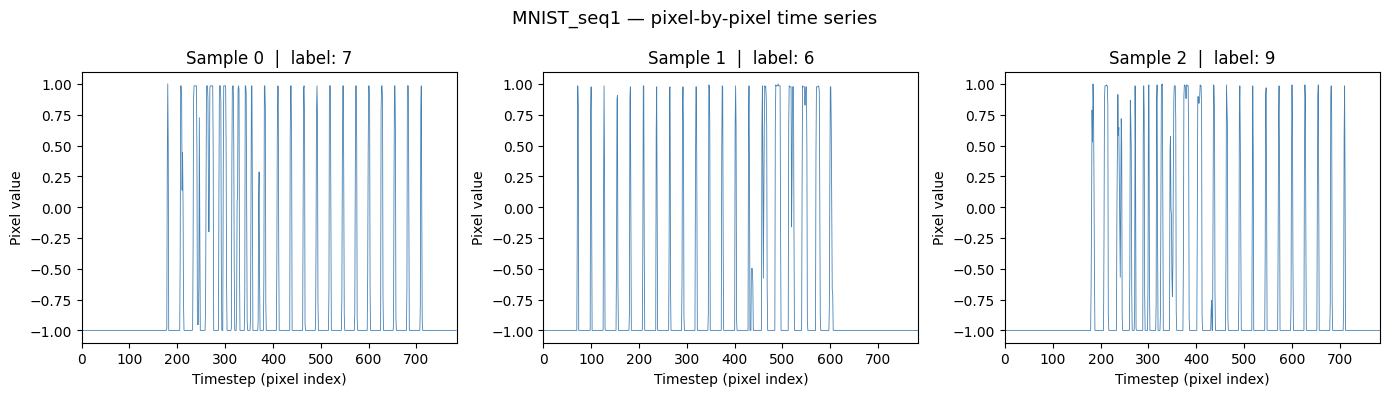

In [6]:
X_seq, labels = load_data_as_sequence("MNIST_seq1", local=True, label_every_step=False)
info_mnist    = load_data("MNIST_seq1", local=True)["info"]
seq_len_mnist = info_mnist["seq_len"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, idx in zip(axes, [0, 1, 2]):
    pixel_signal = X_seq[idx, :, 0]          # shape (784,)
    digit_label  = int(np.argmax(labels[idx]))

    ax.plot(pixel_signal, linewidth=0.6, color='steelblue')
    ax.set_title(f"Sample {idx}  |  label: {digit_label}")
    ax.set_xlabel("Timestep (pixel index)")
    ax.set_ylabel("Pixel value")
    ax.set_xlim(0, seq_len_mnist)

fig.suptitle("MNIST_seq1 — pixel-by-pixel time series", fontsize=13)
plt.tight_layout()
plt.show()

### 5.2  MNIST_seq1 — original 2-D image reconstructed from the sequence

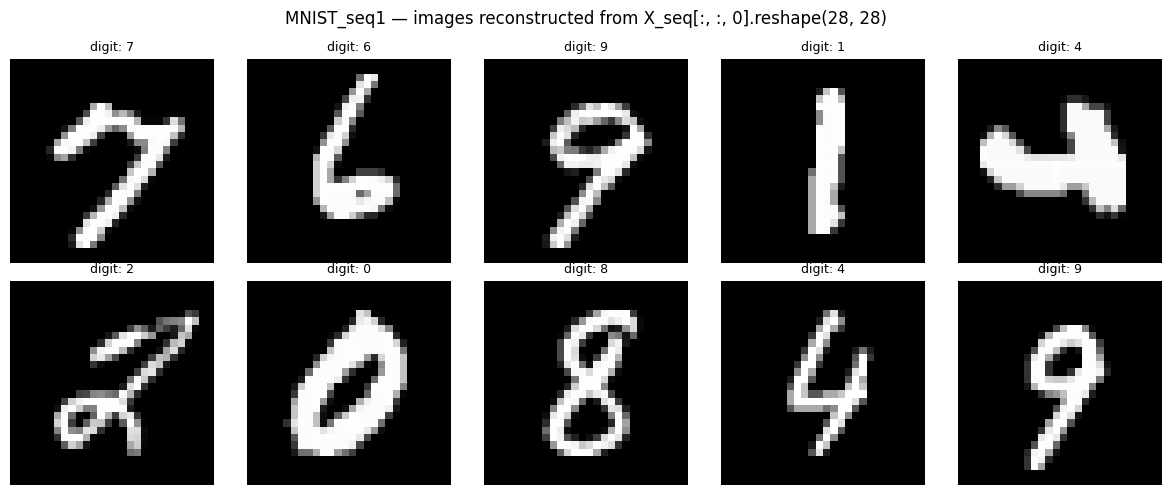

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.ravel(), range(10)):
    img    = X_seq[idx, :, 0].reshape(28, 28)
    label  = int(np.argmax(labels[idx]))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"digit: {label}", fontsize=9)
    ax.axis('off')

fig.suptitle("MNIST_seq1 — images reconstructed from X_seq[:, :, 0].reshape(28, 28)", fontsize=12)
plt.tight_layout()
plt.show()

### 5.3  MNIST1D_seq1 — 1-D signal time series

MNIST1D_seq1 info: {'num_points': 1000, 'size': 50, 'x_y_index': 40, 'x_size': 40, 'y_size': 10, 'onehot_y': 1, 'seq_len': 40, 'step_size': 1, 'data_family': 'MNIST1D'}
X_seq shape: (1000, 40, 1)


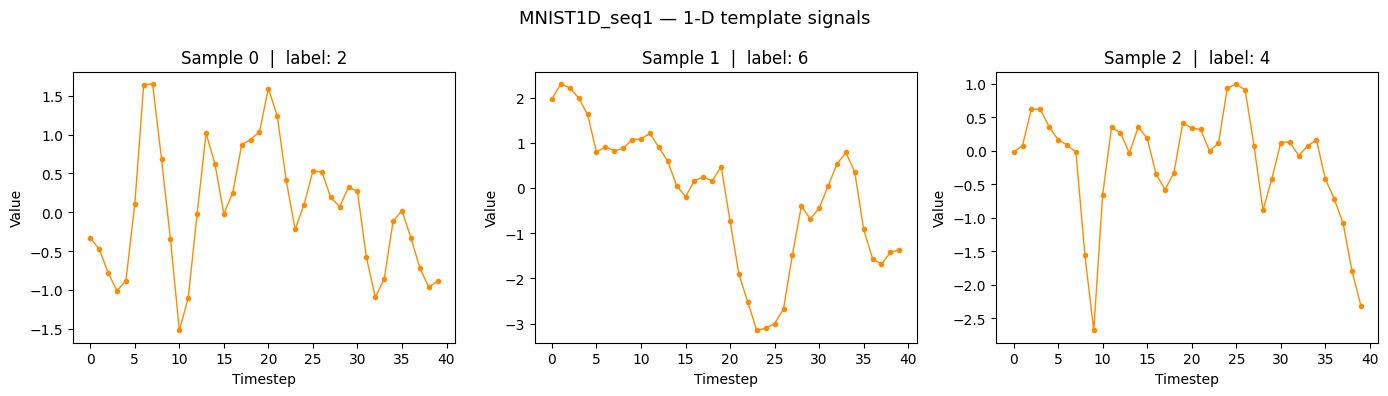

In [8]:
X_1d, labels_1d = load_data_as_sequence("MNIST1D_seq1", local=True, label_every_step=False)
info_1d          = load_data("MNIST1D_seq1", local=True)["info"]

print(f"MNIST1D_seq1 info: {info_1d}")
print(f"X_seq shape: {X_1d.shape}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, idx in zip(axes, [0, 1, 2]):
    signal = X_1d[idx, :, 0]
    label  = int(np.argmax(labels_1d[idx]))
    ax.plot(signal, marker='o', markersize=3, linewidth=1.0, color='darkorange')
    ax.set_title(f"Sample {idx}  |  label: {label}")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Value")

fig.suptitle("MNIST1D_seq1 — 1-D template signals", fontsize=13)
plt.tight_layout()
plt.show()

### 5.4  Sequence heatmap — feature × time

Visualising the full `(seq_len, step_size)` slice of a single sample as a heatmap.  
This is most interesting when `step_size > 1` (e.g. one row of the image per timestep).

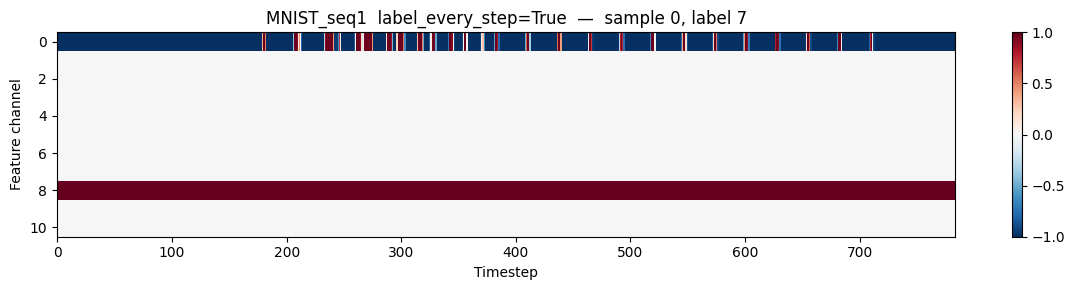

In [9]:
def plot_sequence_heatmap(X_seq, labels, sample_idx=0, title=""):
    """Plot a single sample's sequence as a heatmap (timestep × feature)."""
    seq = X_seq[sample_idx]              # (seq_len, channels)
    label = int(np.argmax(labels[sample_idx]))

    fig, ax = plt.subplots(figsize=(12, 3))
    im = ax.imshow(seq.T, aspect='auto', cmap='RdBu_r',
                   interpolation='nearest')
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Feature channel")
    ax.set_title(f"{title}  —  sample {sample_idx}, label {label}")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# MNIST_seq1 with label embedded (step_size=1, label_dim=10 → 11 channels total)
X_embed, labels_embed = load_data_as_sequence("MNIST_seq1", local=True, label_every_step=True)
plot_sequence_heatmap(X_embed, labels_embed, sample_idx=0,
                      title="MNIST_seq1  label_every_step=True")

### 5.5  Label distribution in the loaded dataset

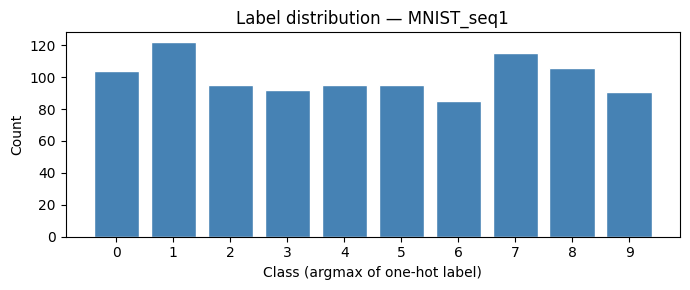

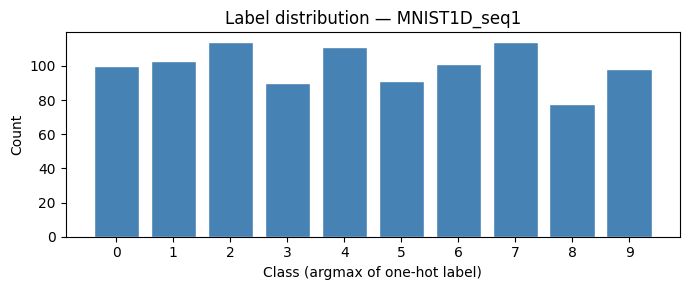

In [10]:
def plot_label_distribution(labels, dataset_name):
    label_ids = np.argmax(labels, axis=1)
    unique, counts = np.unique(label_ids, return_counts=True)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(unique, counts, color='steelblue', edgecolor='white')
    ax.set_xticks(unique)
    ax.set_xlabel("Class (argmax of one-hot label)")
    ax.set_ylabel("Count")
    ax.set_title(f"Label distribution — {dataset_name}")
    plt.tight_layout()
    plt.show()

plot_label_distribution(labels,    "MNIST_seq1")
plot_label_distribution(labels_1d, "MNIST1D_seq1")

---
## 6  Error handling — non-sequence datasets

`load_data_as_sequence` raises a descriptive `ValueError` when called on a dataset that has no sequence metadata.

In [11]:
try:
    load_data_as_sequence("MNIST", local=True)
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Dataset 'MNIST' has no sequence metadata (seq_len / step_size). Use load_data_as_xy() instead, or load a sequence variant such as 'MNIST_seq1'.


---
## 7  Interactive Dataset Explorer

Use the widgets below to browse any sequence dataset.  
Select the dataset, a sample index, and whether to embed the label in the sequence.  
The explorer adapts its visualisation to the dataset's shape.

In [12]:
# --- cache to avoid reloading on every slider move ---
_cache = {}

def get_seq_data(name, label_every_step):
    key = (name, label_every_step)
    if key not in _cache:
        _cache[key] = load_data_as_sequence(name, local=True,
                                            label_every_step=label_every_step)
    return _cache[key]

def get_info(name):
    if name not in _cache:
        _cache[name] = load_data(name, local=True)["info"]
    return _cache[name]


def explorer_plot(dataset_name, sample_idx, label_every_step, show_image):
    info = get_info(dataset_name)
    seq_len   = info["seq_len"]
    step_size = info["step_size"]
    label_dim = info["y_size"]
    n_points  = info["num_points"]

    X_seq, labels = get_seq_data(dataset_name, label_every_step)

    sample_idx = min(sample_idx, n_points - 1)
    seq    = X_seq[sample_idx]                   # (seq_len, channels)
    lbl    = labels[sample_idx]                  # (label_dim,)
    digit  = int(np.argmax(lbl))
    channels = seq.shape[1]

    # ---- figure layout ----
    is_mnist_family = (step_size == 1 and seq_len == 784 and show_image)
    is_mnist1d      = (seq_len == 40)
    ncols = 3 if is_mnist_family else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))

    ax_signal = axes[0]
    ax_heat   = axes[1]

    # ---- signal plot ----
    pixel_signal = seq[:, 0]         # first (pixel) channel only
    ax_signal.plot(pixel_signal, linewidth=0.7,
                   color='steelblue' if not is_mnist1d else 'darkorange',
                   marker='o' if is_mnist1d else None,
                   markersize=3)
    ax_signal.set_title(f"Pixel signal  (ch 0)  |  label: {digit}")
    ax_signal.set_xlabel("Timestep")
    ax_signal.set_ylabel("Value")

    # ---- heatmap ----
    im = ax_heat.imshow(seq.T, aspect='auto', cmap='RdBu_r',
                        interpolation='nearest')
    ax_heat.set_xlabel("Timestep")
    ax_heat.set_ylabel("Feature channel")
    lbl_tag = f"(+{label_dim} label ch)" if label_every_step else "(pixels only)"
    ax_heat.set_title(f"Heatmap  {channels} ch  {lbl_tag}")
    plt.colorbar(im, ax=ax_heat)

    # ---- image reconstruction (MNIST only) ----
    if is_mnist_family:
        ax_img = axes[2]
        img = pixel_signal.reshape(28, 28)
        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(f"28×28 image  |  digit: {digit}")
        ax_img.axis('off')

    meta = (f"Dataset: {dataset_name}  |  sample {sample_idx}/{n_points-1}  |  "
            f"seq_len={seq_len}  step_size={step_size}  label_dim={label_dim}")
    fig.suptitle(meta, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

    # ---- label bar ----
    fig2, ax2 = plt.subplots(figsize=(5, 2))
    ax2.bar(range(label_dim), lbl, color=['tab:orange' if i == digit else 'tab:blue'
                                          for i in range(label_dim)])
    ax2.set_xticks(range(label_dim))
    ax2.set_xlabel("Class")
    ax2.set_ylabel("One-hot value")
    ax2.set_title(f"Label vector  (predicted class = {digit})")
    plt.tight_layout()
    plt.show()


# ---- build widgets ----
w_dataset = widgets.Dropdown(
    options=seq_names,
    value=seq_names[0] if seq_names else None,
    description='Dataset:',
    layout=widgets.Layout(width='300px'),
)

w_sample = widgets.IntSlider(
    value=0, min=0, max=999, step=1,
    description='Sample:',
    continuous_update=False,
    layout=widgets.Layout(width='400px'),
)

w_label_step = widgets.Checkbox(
    value=True,
    description='label_every_step',
)

w_show_img = widgets.Checkbox(
    value=True,
    description='Show 2-D image (MNIST)',
)

def _on_dataset_change(change):
    """Update sample slider max when dataset changes."""
    info = get_info(change['new'])
    w_sample.max = info['num_points'] - 1
    w_sample.value = 0

w_dataset.observe(_on_dataset_change, names='value')

ui = widgets.VBox([
    widgets.HBox([w_dataset, w_sample]),
    widgets.HBox([w_label_step, w_show_img]),
])

out = widgets.interactive_output(
    explorer_plot,
    dict(
        dataset_name   = w_dataset,
        sample_idx     = w_sample,
        label_every_step = w_label_step,
        show_image     = w_show_img,
    )
)

display(ui, out)

Output()

---
## 8  Using sequence data in a training loop

A minimal PyTorch-style snippet showing how the shapes fit a standard RNN / LSTM.

In [13]:
import torch

X_seq_np, labels_np = load_data_as_sequence(
    "MNIST1D_seq1", local=True, label_every_step=True
)

# Convert to torch tensors
X_tensor = torch.tensor(X_seq_np, dtype=torch.float32)   # (N, T, C)
y_tensor = torch.tensor(np.argmax(labels_np, axis=1), dtype=torch.long)  # (N,)

print("X_tensor shape (batch, seq_len, channels):", X_tensor.shape)
print("y_tensor shape (batch,)                  :", y_tensor.shape)

# PyTorch RNN / LSTM expects (seq_len, batch, input_size) by default,
# or (batch, seq_len, input_size) with batch_first=True.
# e.g.:
#   rnn = torch.nn.LSTM(input_size=X_tensor.shape[2], hidden_size=64, batch_first=True)
#   output, (h_n, c_n) = rnn(X_tensor)
print("\nReady for: nn.LSTM(input_size=%d, hidden_size=..., batch_first=True)" % X_tensor.shape[2])

X_tensor shape (batch, seq_len, channels): torch.Size([1000, 40, 11])
y_tensor shape (batch,)                  : torch.Size([1000])

Ready for: nn.LSTM(input_size=11, hidden_size=..., batch_first=True)
